# 1. 데이터 불러오기 및 결측치 처리

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('prj_data.csv')
df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,메모,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,재구매 유도 대상,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,재구매 유도 대상,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,NaN,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,재구매 유도 대상,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,NaN,0


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     500 non-null    str    
 1   나이       460 non-null    float64
 2   성별       485 non-null    str    
 3   거주지역     500 non-null    str    
 4   가입경로     480 non-null    str    
 5   멤버십등급    500 non-null    str    
 6   월평균구매금액  500 non-null    float64
 7   구매횟수     500 non-null    float64
 8   리뷰점수     475 non-null    float64
 9   쿠폰사용여부   500 non-null    str    
 10  메모       216 non-null    str    
 11  이탈여부     500 non-null    int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 64.3 KB


In [36]:
df.isnull().sum()

고객ID         0
나이          40
성별          15
거주지역         0
가입경로        20
멤버십등급        0
월평균구매금액      0
구매횟수         0
리뷰점수        25
쿠폰사용여부       0
메모         284
이탈여부         0
dtype: int64

In [37]:
missing_ratio = df.isnull().mean()
missing_ratio

고객ID       0.000
나이         0.080
성별         0.030
거주지역       0.000
가입경로       0.040
멤버십등급      0.000
월평균구매금액    0.000
구매횟수       0.000
리뷰점수       0.050
쿠폰사용여부     0.000
메모         0.568
이탈여부       0.000
dtype: float64

In [38]:
# 결측치 50% 이상 컬럼 삭제
drop_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
df = df.drop(columns=drop_cols)
df

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,0
...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,39.0,여,경기,웹,골드,108578.954159,9.0,3.5,N,0
496,C0497,24.0,여,대구,광고,브론즈,40162.047877,6.0,3.6,N,1
497,C0498,37.0,남,서울,웹,브론즈,51493.570059,3.0,4.1,Y,0
498,C0499,66.0,여,기타,앱,골드,105068.989111,6.0,4.4,N,0


In [39]:
missing_ratio_after = df.isnull().mean()
missing_ratio_after

고객ID       0.00
나이         0.08
성별         0.03
거주지역       0.00
가입경로       0.04
멤버십등급      0.00
월평균구매금액    0.00
구매횟수       0.00
리뷰점수       0.05
쿠폰사용여부     0.00
이탈여부       0.00
dtype: float64

In [40]:
# 수치형 변수의 결측치를 평균값으로 변경
num_cols_na = df.select_dtypes(include='number').columns
num_cols_na

Index(['나이', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부'], dtype='str')

In [41]:
num_cols_na = num_cols_na[df[num_cols_na].isnull().any()]
num_cols_na

Index(['나이', '리뷰점수'], dtype='str')

In [42]:
target_cols = ['나이', '리뷰점수']
df[target_cols] = df[target_cols].fillna(df[target_cols].mean())

In [43]:
# 범주형 변수의 결측치를 최빈값으로 변경
cat_cols_na = df.select_dtypes(exclude='number').columns
cat_cols_na

Index(['고객ID', '성별', '거주지역', '가입경로', '멤버십등급', '쿠폰사용여부'], dtype='str')

In [44]:
cat_cols_na = cat_cols_na[df[cat_cols_na].isnull().any()]
cat_cols_na

Index(['성별', '가입경로'], dtype='str')

In [45]:
target_cols_cat = ['성별', '가입경로']
df[target_cols_cat] = df[target_cols_cat].fillna(df[target_cols_cat].mode().iloc[0])

In [46]:
# 결측치 제거 후 확인
df.isnull().sum()

고객ID       0
나이         0
성별         0
거주지역       0
가입경로       0
멤버십등급      0
월평균구매금액    0
구매횟수       0
리뷰점수       0
쿠폰사용여부     0
이탈여부       0
dtype: int64

# 2.이상치 탐색 처리

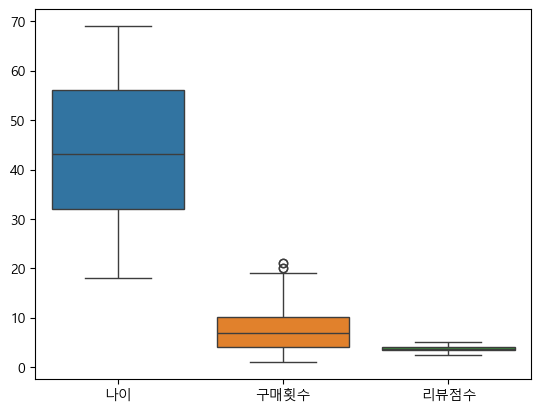

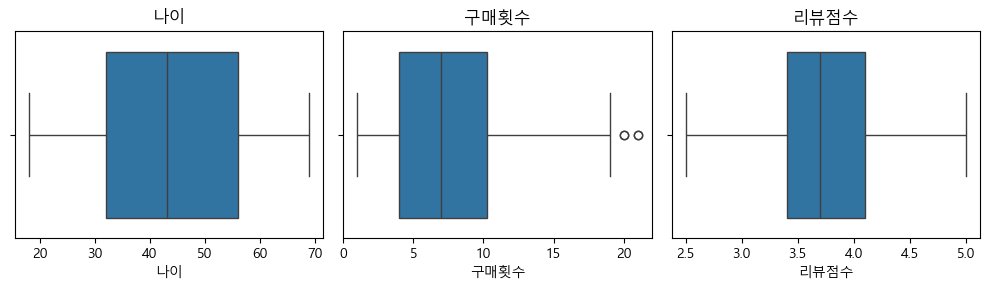

In [47]:
# 이상치 시각화
outlier_cols = ['나이', '구매횟수', '리뷰점수']
sns.boxplot(data=df[outlier_cols])
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for col, ax in zip(outlier_cols, axes.flat):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()

In [48]:
# IQR 경계값 계산
q1 = df['리뷰점수'].quantile(.25)
q3 = df['리뷰점수'].quantile(.75)

q1, q3

(np.float64(3.4), np.float64(4.1))

In [49]:
iqr = q3 -q1
iqr

np.float64(0.6999999999999997)

In [50]:
# 하한
lower = q1 - 1.5 * iqr
# 상한
upper = q3 + 1.5 * iqr

lower, upper

(np.float64(2.3500000000000005), np.float64(5.1499999999999995))

In [51]:
# 경계값 기준 이상치를 개수
n_outlier = ((df['리뷰점수'] < lower) | (df['리뷰점수'] > upper)).sum()
n_outlier

np.int64(0)

In [52]:
# 경계값 기준 이상치를 경계값으로 대체

# 5점 만점인 리뷰 점수에서 상한값이 5.14이지만 5를 넘길 수 없지만 제거를 하게 되면 5점인 리뷰도 제거되게 되고
# 하한값 2.35보다 낮고 0점 이상인 점수는 나올 수 있지만 제거를 하게 되면 고객의 불만이나 이탈을 분석하지 못하게 되어 대체하였습니다. 
df['리뷰점수'] = df['리뷰점수'].clip(lower, upper)
df['리뷰점수']

0      3.3
1      4.7
2      3.3
3      3.8
4      4.9
      ... 
495    3.5
496    3.6
497    4.1
498    4.4
499    4.3
Name: 리뷰점수, Length: 500, dtype: float64

# 3.범주형 변수 인코딩

In [53]:
df_before = df.copy()
df_before

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.000000,남,대구,앱,실버,62705.653045,7.0,3.3,N,1
1,C0002,58.000000,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,0
2,C0003,52.000000,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,0
3,C0004,40.000000,여,경기,앱,실버,71563.606370,3.0,3.8,N,0
4,C0005,40.000000,남,경기,웹,골드,107967.380320,7.0,4.9,N,0
...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,39.000000,여,경기,웹,골드,108578.954159,9.0,3.5,N,0
496,C0497,24.000000,여,대구,광고,브론즈,40162.047877,6.0,3.6,N,1
497,C0498,37.000000,남,서울,웹,브론즈,51493.570059,3.0,4.1,Y,0
498,C0499,66.000000,여,기타,앱,골드,105068.989111,6.0,4.4,N,0


In [54]:
# 레이블 인코딩
le = LabelEncoder()
pd.set_option('display.max_columns', None)
df['멤버십등급_Encoder'] = le.fit_transform(df['멤버십등급'])

# 멤버십 등급은 순서의 의미가 있는 컬럼이기 때문에 레이블 인코딩을 사용하였습니다

df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부,멤버십등급_Encoder
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,1,3
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,0,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,0,2
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,0,3
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,0,1


In [55]:
oh = OneHotEncoder()
nom_cols = ['거주지역', '성별', '가입경로', '쿠폰사용여부']

# 거주지역, 성별, 가입경로, 쿠폰사용여부는 순서의 의미가 없기 때문에 원-핫 인코딩을 사용하였습니다

df = pd.get_dummies(df, columns=nom_cols, dtype=int)

df.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,멤버십등급_Encoder,거주지역_경기,거주지역_기타,거주지역_대구,거주지역_부산,거주지역_서울,성별_남,성별_여,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y
0,C0001,22.0,실버,62705.653045,7.0,3.3,1,3,0,0,1,0,0,1,0,0,1,0,0,1,0
1,C0002,58.0,VIP,180896.754122,18.0,4.7,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1
2,C0003,52.0,브론즈,30567.640969,3.0,3.3,0,2,0,1,0,0,0,0,1,0,1,0,0,0,1
3,C0004,40.0,실버,71563.606370,3.0,3.8,0,3,1,0,0,0,0,0,1,0,1,0,0,1,0
4,C0005,40.0,골드,107967.380320,7.0,4.9,0,1,1,0,0,0,0,1,0,0,0,1,0,1,0


In [56]:
# 인코딩 전/후의 shape와 컬럼 목록 비교
print(f'인코딩 전 :{df_before.shape}')
print(f'인코딩 후 :{df.shape}')
print("-"*50)
print(f'인코딩 전 ({df_before.columns})')
print(f'인코딩 후 ({df.columns})')

인코딩 전 :(500, 11)
인코딩 후 :(500, 21)
--------------------------------------------------
인코딩 전 (Index(['고객ID', '나이', '성별', '거주지역', '가입경로', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수',
       '쿠폰사용여부', '이탈여부'],
      dtype='str'))
인코딩 후 (Index(['고객ID', '나이', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부',
       '멤버십등급_Encoder', '거주지역_경기', '거주지역_기타', '거주지역_대구', '거주지역_부산', '거주지역_서울',
       '성별_남', '성별_여', '가입경로_광고', '가입경로_앱', '가입경로_웹', '가입경로_지인추천', '쿠폰사용여부_N',
       '쿠폰사용여부_Y'],
      dtype='str'))


# 4. 파생변수 생성 및 스케일링

In [57]:
# 파생변수
df['Buy'] = df['월평균구매금액'] / df['구매횟수']

df.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,멤버십등급_Encoder,거주지역_경기,거주지역_기타,거주지역_대구,거주지역_부산,거주지역_서울,성별_남,성별_여,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,Buy
0,C0001,22.0,실버,62705.653045,7.0,3.3,1,3,0,0,1,0,0,1,0,0,1,0,0,1,0,8957.950435
1,C0002,58.0,VIP,180896.754122,18.0,4.7,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,10049.819673
2,C0003,52.0,브론즈,30567.640969,3.0,3.3,0,2,0,1,0,0,0,0,1,0,1,0,0,0,1,10189.213656
3,C0004,40.0,실버,71563.606370,3.0,3.8,0,3,1,0,0,0,0,0,1,0,1,0,0,1,0,23854.535457
4,C0005,40.0,골드,107967.380320,7.0,4.9,0,1,1,0,0,0,0,1,0,0,0,1,0,1,0,15423.911474


In [58]:
# 스케일링 전 기술통계량
scale_cols = ['월평균구매금액', '구매횟수', 'Buy']
df[scale_cols].describe().loc[['mean', 'std']].round(4)

,월평균구매금액,구매횟수,Buy
mean,97684.0034,7.8220,14985.7545
std,106309.9408,4.4818,20193.2963


In [59]:
# 스케일링 후 기술통계량
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df[scale_cols].describe().loc[['mean', 'std']].round(4)

,월평균구매금액,구매횟수,Buy
mean,0.000,-0.000,0.000
std,1.001,1.001,1.001


In [60]:
# 최종 전처리 완료 데이터 저장
df.to_csv('prj_data_cleaned.csv', index=False)

pd.read_csv('prj_data_cleaned.csv')

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,멤버십등급_Encoder,거주지역_경기,거주지역_기타,거주지역_대구,거주지역_부산,거주지역_서울,성별_남,성별_여,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,Buy
0,C0001,22.000000,실버,-0.329352,-0.183592,3.3,1,3,0,0,1,0,0,1,0,0,1,0,0,1,0,-0.298804
1,C0002,58.000000,VIP,0.783521,2.273239,4.7,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,-0.244679
2,C0003,52.000000,브론즈,-0.631960,-1.076986,3.3,0,2,0,1,0,0,0,0,1,0,1,0,0,0,1,-0.237769
3,C0004,40.000000,실버,-0.245946,-1.076986,3.8,0,3,1,0,0,0,0,0,1,0,1,0,0,1,0,0.439634
4,C0005,40.000000,골드,0.096827,-0.183592,4.9,0,1,1,0,0,0,0,1,0,0,0,1,0,1,0,0.021720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,39.000000,골드,0.102586,0.263104,3.5,0,1,1,0,0,0,0,0,1,0,0,1,0,1,0,-0.144818
496,C0497,24.000000,브론즈,-0.541620,-0.406941,3.6,1,2,0,0,1,0,0,0,1,1,0,0,0,1,0,-0.411047
497,C0498,37.000000,브론즈,-0.434924,-1.076986,4.1,0,2,0,0,0,0,1,1,0,0,0,1,0,0,1,0.108004
498,C0499,66.000000,골드,0.069536,-0.406941,4.4,0,1,0,1,0,0,0,0,1,0,1,0,0,1,0,0.125204
